## Cross-Subject Sleep Stage Classification from EEG Signals
* **Course:** Machine Learning 90 | **Group ID:** ML_DS_90_02
* **Team:** Anupriya Segar | Sandip Waingade | Naiyaben Patel
* **Date:** 10 July 2026

## Problem Statement

Sleep-stage classification models often perform well when training and testing data contain recordings from the same subjects.

However, performance usually drops when predicting sleep stages for completely unseen subjects.

This project investigates:

- Can EEG signals be used to classify sleep stages?
- How well do models generalize to new subjects?
- Do neural models outperform classical spectral-feature approaches?
- Which sleep stages are hardest to classify?

The focus is on:

* Cross-subject generalization, Leave-subject-out evaluation

* Comparison of classical ML and neural models



## Dataset
- **Source:** Sleep-EDF Database Expanded (PhysioNet), sleep-cassette subset
- **Subset used:** 30 subjects (LOSO), selected for computational feasibility
  on Colab — full 153-subject set was preprocessed but not used for the
  final model comparison due to compute/time constraints
- **Channels:** EEG Fpz-Cz, Pz-Oz (100 Hz)
- **Labels:** 5 AASM stages — Wake, N1, N2, N3, REM
- **Epochs:** 30-second windows, wake-trimmed, bandpass filtered 0.5–30 Hz

# Selected Models
* Random Forest
* 1D CNN
* CNN-LSTM



## Phase 1: Dataset Understanding & Exploration

In [ ]:
# Install Libraries

!pip install mne matplotlib seaborn scipy pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 20.2 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
# Imports

from pathlib import Path
from collections import Counter

import os
import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import mne

import warnings

# Suppress non-critical warnings to keep notebook output clean

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')   # MNE only prints if something is actually wrong

print("All libraries imported successfully")


All libraries imported successfully


In [ ]:
# ============================================================
# REPRODUCIBILITY
# ============================================================

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

## # Phase 1 – Load Sleep-EDF Dataset

Load the EEG recordings and corresponding hypnogram annotations required for sleep stage classification.

In [ ]:
# Google Drive Mount

from google.colab import drive

drive.mount('/content/drive')

DATA_DIR = Path("/content/drive/MyDrive/sleep_edf/sleep-cassette")

print(DATA_DIR.exists())

Mounted at /content/drive
True


In [ ]:
# List the EDF Files

edf_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.edf")))

print('-'*60)
print("Total EDF files:", len(edf_files))
print('-'*60)

print('\n'. join(edf_files[:10]))


# PSG & Hypnograms Files

print('\n')
print('-'*60)
print('No.of PSG & Hypnogram Files')
print('-'*60)

psg_files = sorted(DATA_DIR.glob("*PSG.edf"))
hyp_files = sorted(DATA_DIR.glob("*Hypnogram.edf"))

print("PSG Files :", len(psg_files))
print("Hypnograms:", len(hyp_files))


------------------------------------------------------------
Total EDF files: 306
------------------------------------------------------------
/content/drive/MyDrive/sleep_edf/sleep-cassette/SC4001E0-PSG.edf
/content/drive/MyDrive/sleep_edf/sleep-cassette/SC4001EC-Hypnogram.edf
/content/drive/MyDrive/sleep_edf/sleep-cassette/SC4002E0-PSG.edf
/content/drive/MyDrive/sleep_edf/sleep-cassette/SC4002EC-Hypnogram.edf
/content/drive/MyDrive/sleep_edf/sleep-cassette/SC4011E0-PSG.edf
/content/drive/MyDrive/sleep_edf/sleep-cassette/SC4011EH-Hypnogram.edf
/content/drive/MyDrive/sleep_edf/sleep-cassette/SC4012E0-PSG.edf
/content/drive/MyDrive/sleep_edf/sleep-cassette/SC4012EC-Hypnogram.edf
/content/drive/MyDrive/sleep_edf/sleep-cassette/SC4021E0-PSG.edf
/content/drive/MyDrive/sleep_edf/sleep-cassette/SC4021EH-Hypnogram.edf


------------------------------------------------------------
No.of PSG & Hypnogram Files
------------------------------------------------------------
PSG Files : 153
Hypnogram

## Dataset Overview

Explores the Sleep-EDF dataset, including the EEG recordings, channels, and recording information.

In [ ]:
# Inspect One Recording

sample_file = edf_files[0]
print(sample_file)


# Load EDF Header

raw = mne.io.read_raw_edf(
    sample_file,
    preload=False,
    verbose=False
)

/content/drive/MyDrive/sleep_edf/sleep-cassette/SC4001E0-PSG.edf


In [ ]:
# Inspect Available Channels

print('-'*60)
print("Channels Available:")
print('-'*60)

for ch in raw.ch_names:
    print(ch)

------------------------------------------------------------
Channels Available:
------------------------------------------------------------
EEG Fpz-Cz
EEG Pz-Oz
EOG horizontal
Resp oro-nasal
EMG submental
Temp rectal
Event marker


In [ ]:
# Basic Recording Information

print("Sampling Frequency:", raw.info['sfreq'])
print("Duration (minutes):", raw.times[-1] / 60)

Sampling Frequency: 100.0
Duration (minutes): 1324.9998333333335


## Sample EEG Recording

The following plot shows a sample EEG recording from one subject. It provides an overview of the brain signal before preprocessing.

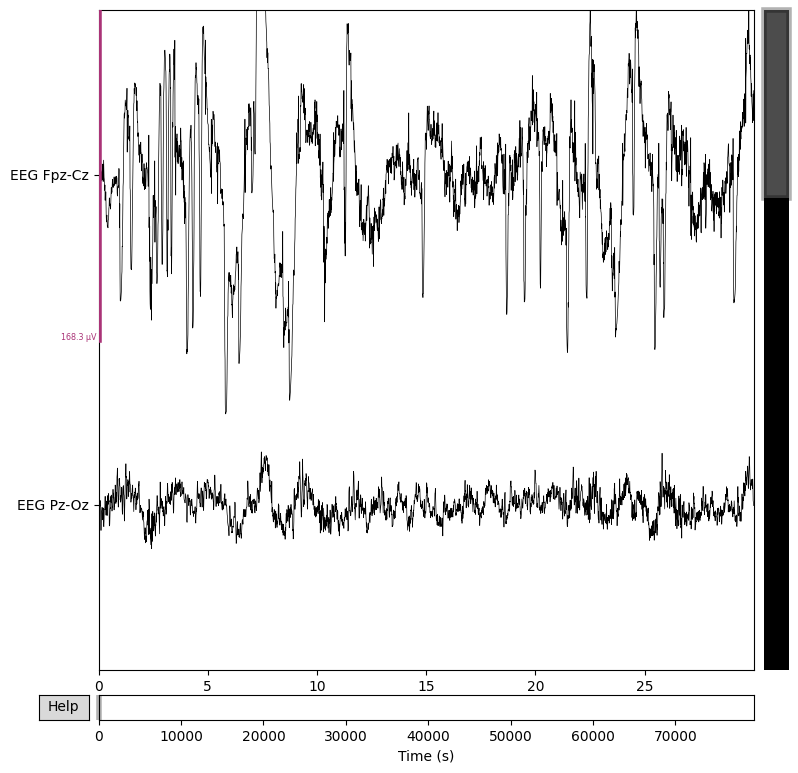

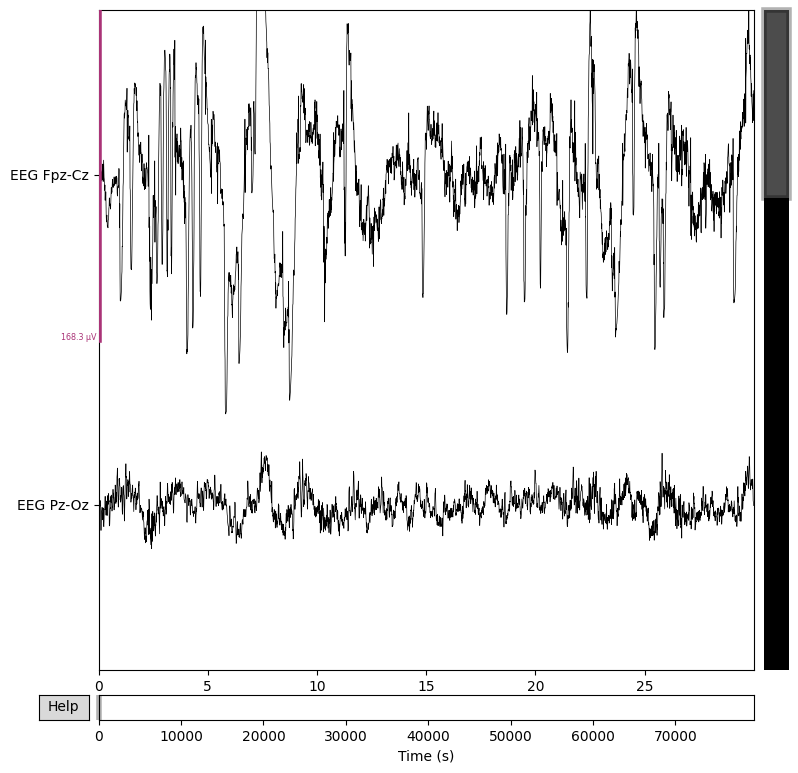

In [ ]:
# Plot

raw.load_data()

raw.plot(
    start=0,
    duration=30,
    n_channels=2,
    scalings='auto'
)

**Observation**

The EEG recording contains continuous brain activity with varying amplitudes over time. These raw signals require preprocessing before model training.

# Phase 2: Understanding Sleep Labels

Goal of Phase 2 - Load one subject and inspect the sleep annotation

In [ ]:
psg_files = sorted(glob.glob(os.path.join(DATA_DIR, "*PSG.edf")))
hyp_files = sorted(glob.glob(os.path.join(DATA_DIR, "*Hypnogram.edf")))

print("Total PSG Files:", len(psg_files))
print("Total Hypnogram Files:", len(hyp_files))

print("\nExample PSG:")
print(psg_files[0])

print("\nMatching Hypnogram:")
print(hyp_files[0])

Total PSG Files: 153
Total Hypnogram Files: 153

Example PSG:
/content/drive/MyDrive/sleep_edf/sleep-cassette/SC4001E0-PSG.edf

Matching Hypnogram:
/content/drive/MyDrive/sleep_edf/sleep-cassette/SC4001EC-Hypnogram.edf


In [ ]:
psg = mne.io.read_raw_edf(
    psg_files[0],
    preload=False,
    verbose=False
)

print(psg)

<RawEDF | SC4001E0-PSG.edf, 7 x 7950000 (79500.0 s), ~10 KiB, data not loaded>


## Sleep Stage Annotations

Each EEG recording is accompanied by manually annotated sleep stages.

In [ ]:
annot = mne.read_annotations(hyp_files[0])

print(annot)

<Annotations | 154 segments: Sleep stage 1 (24), Sleep stage 2 (40), Sleep ...>


In [ ]:
for i in range(20):
    print(
        f"Onset={annot.onset[i]:8.1f} sec | "
        f"Duration={annot.duration[i]:6.1f} sec | "
        f"Label={annot.description[i]}"
    )

Onset=     0.0 sec | Duration=30630.0 sec | Label=Sleep stage W
Onset= 30630.0 sec | Duration= 120.0 sec | Label=Sleep stage 1
Onset= 30750.0 sec | Duration= 390.0 sec | Label=Sleep stage 2
Onset= 31140.0 sec | Duration=  30.0 sec | Label=Sleep stage 3
Onset= 31170.0 sec | Duration=  30.0 sec | Label=Sleep stage 2
Onset= 31200.0 sec | Duration= 150.0 sec | Label=Sleep stage 3
Onset= 31350.0 sec | Duration=  30.0 sec | Label=Sleep stage 4
Onset= 31380.0 sec | Duration=  60.0 sec | Label=Sleep stage 3
Onset= 31440.0 sec | Duration=  60.0 sec | Label=Sleep stage 4
Onset= 31500.0 sec | Duration=  30.0 sec | Label=Sleep stage 3
Onset= 31530.0 sec | Duration= 120.0 sec | Label=Sleep stage 4
Onset= 31650.0 sec | Duration=  30.0 sec | Label=Sleep stage 3
Onset= 31680.0 sec | Duration= 120.0 sec | Label=Sleep stage 4
Onset= 31800.0 sec | Duration=  30.0 sec | Label=Sleep stage W
Onset= 31830.0 sec | Duration=  60.0 sec | Label=Sleep stage 3
Onset= 31890.0 sec | Duration=  60.0 sec | Label=Sleep

In [ ]:
label_counts = pd.Series(annot.description).value_counts()

print(label_counts)

Sleep stage 3    48
Sleep stage 2    40
Sleep stage 1    24
Sleep stage 4    23
Sleep stage W    12
Sleep stage R     6
Sleep stage ?     1
Name: count, dtype: int64


# Phase 3: Epoch Creation & Label Alignment


Total PSG files: 153
Total Hypnogram files: 153

Selected PSG:
/content/drive/MyDrive/sleep_edf/sleep-cassette/SC4001E0-PSG.edf

Selected Hypnogram:
/content/drive/MyDrive/sleep_edf/sleep-cassette/SC4001EC-Hypnogram.edf

Subject ID: SC4001E0

Raw EEG Loaded Successfully

Selected Channels:
['EEG Fpz-Cz', 'EEG Pz-Oz']

Annotations Loaded
<Annotations | 154 segments: Sleep stage 1 (24), Sleep stage 2 (40), Sleep ...>

Unique Annotation Labels:
['Sleep stage 1' 'Sleep stage 2' 'Sleep stage 3' 'Sleep stage 4'
 'Sleep stage ?' 'Sleep stage R' 'Sleep stage W']

Label Mapping:
{'Sleep stage W': 0, 'Sleep stage 1': 1, 'Sleep stage 2': 2, 'Sleep stage 3': 3, 'Sleep stage 4': 3, 'Sleep stage R': 4}

Number of Events: 2650

Epoch Creation Complete

Epoch Tensor Shape:
(2650, 2, 3000)

Tensor Meaning:
Number of Epochs = 2650
Number of Channels = 2
Samples Per Epoch = 3000

Label Vector Shape:
(2650,)

Unique Labels:
[0 1 2 3 4]

Class Distribution

Wake  : 1997
N1    : 58
N2    : 250
N3    : 220
R

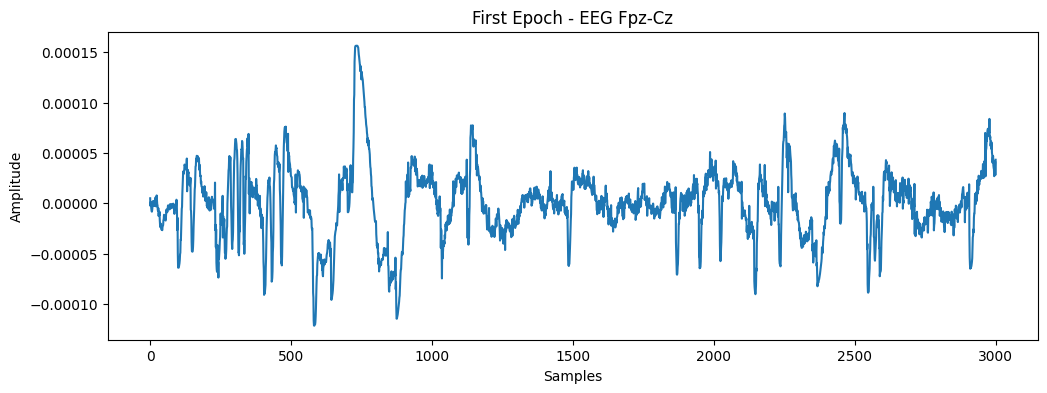


Verification
Epoch Duration: 30.0 seconds


In [ ]:
# ============================================================
# PHASE 3
# EEG EPOCH CREATION & LABEL ALIGNMENT
# ============================================================


# ============================================================
# STEP 1: Locate PSG and Hypnogram Files
# ============================================================

psg_files = sorted(
    glob.glob(os.path.join(DATA_DIR, "*PSG.edf"))
)

hyp_files = sorted(
    glob.glob(os.path.join(DATA_DIR, "*Hypnogram.edf"))
)

print("Total PSG files:", len(psg_files))
print("Total Hypnogram files:", len(hyp_files))


# ============================================================
# STEP 2: Select One Recording
# ============================================================

psg_file = psg_files[0]
hyp_file = hyp_files[0]

print("\nSelected PSG:")
print(psg_file)

print("\nSelected Hypnogram:")
print(hyp_file)

# ============================================================
# STEP 3: Extract Subject ID
# ============================================================

# Important later for LOSO validation

subject_id = os.path.basename(psg_file).split("-")[0]

print("\nSubject ID:", subject_id)

# ============================================================
# STEP 4: Load EEG Recording
# ============================================================

# preload=True because we now need actual EEG values

raw = mne.io.read_raw_edf(
    psg_file,
    preload=True,
    verbose=False
)

print("\nRaw EEG Loaded Successfully")

# ============================================================
# STEP 5: Keep ONLY EEG Channels
# ============================================================

raw.pick([
    "EEG Fpz-Cz",
    "EEG Pz-Oz"
])

print("\nSelected Channels:")
print(raw.ch_names)

# ============================================================
# STEP 6: Load Sleep Stage Annotations
# ============================================================

annotations = mne.read_annotations(hyp_file)

print("\nAnnotations Loaded")
print(annotations)

# ============================================================
# STEP 7: Check Available Labels
# ============================================================

print("\nUnique Annotation Labels:")

print(
    np.unique(
        annotations.description
    )
)

# ============================================================
# STEP 8: Attach Annotations To EEG
# ============================================================

# This links: EEG Signal + Sleep Labels

raw.set_annotations(annotations)

# ============================================================
# STEP 9: Sleep Stage Mapping
# ============================================================

annotation_desc_2_event_id = {

    'Sleep stage W': 0,

    'Sleep stage 1': 1,

    'Sleep stage 2': 2,

    'Sleep stage 3': 3,

    'Sleep stage 4': 3,

    'Sleep stage R': 4
}

print("\nLabel Mapping:")
print(annotation_desc_2_event_id)

# ============================================================
# STEP 10: Create Events
# ============================================================

events, event_id = mne.events_from_annotations(
    raw,
    event_id=annotation_desc_2_event_id,
    chunk_duration=30.0,
    verbose=False
)

print("\nNumber of Events:", len(events))

# ============================================================
# STEP 11: Create EEG Epochs
# ============================================================

epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=0,
    tmax=30 - (1/raw.info['sfreq']),
    baseline=None,
    preload=True,
    verbose=False
)

print("\nEpoch Creation Complete")

# ============================================================
# STEP 12: Extract EEG Data
# ============================================================

X = epochs.get_data()

print("\nEpoch Tensor Shape:")
print(X.shape)

print("\nTensor Meaning:")
print("Number of Epochs =", X.shape[0])
print("Number of Channels =", X.shape[1])
print("Samples Per Epoch =", X.shape[2])

# ============================================================
# STEP 13: Extract Labels
# ============================================================

y = epochs.events[:, -1]

print("\nLabel Vector Shape:")
print(y.shape)

print("\nUnique Labels:")
print(np.unique(y))

# ============================================================
# STEP 14: Label Dictionary
# ============================================================

label_map = {

    0: "Wake",

    1: "N1",

    2: "N2",

    3: "N3",

    4: "REM"
}

# ============================================================
# STEP 15: Class Distribution
# ============================================================

print("\nClass Distribution\n")

label_counts = (
    pd.Series(y)
    .value_counts()
    .sort_index()
)

for label, count in label_counts.items():

    print(
        f"{label_map[label]:<5} : {count}"
    )

# ============================================================
# STEP 16: Visualize One Epoch
# ============================================================

plt.figure(figsize=(12,4))

plt.plot(
    X[0][0]
)

plt.title(
    "First Epoch - EEG Fpz-Cz"
)

plt.xlabel(
    "Samples"
)

plt.ylabel(
    "Amplitude"
)

plt.show()

# ============================================================
# STEP 17: Verify Epoch Length
# ============================================================

print("\nVerification")

epoch_seconds = (
    X.shape[2] /
    raw.info['sfreq']
)

print(
    "Epoch Duration:",
    epoch_seconds,
    "seconds"
)

# Expected:
# 30 seconds

# Phase 4: Data Preprocessing & Dataset Preparation

In [ ]:
# ============================================================
# PHASE 4
# DATA PREPROCESSING & DATASET ANALYSIS
# ============================================================


# Basic Dataset Statistics

print("="*50)
print("DATASET SUMMARY")
print("="*50)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTotal Epochs:", len(y))
print("Channels:", X.shape[1])
print("Samples per Epoch:", X.shape[2])

DATASET SUMMARY
X shape: (2650, 2, 3000)
y shape: (2650,)

Total Epochs: 2650
Channels: 2
Samples per Epoch: 3000


In [ ]:
# Sleep Stage Distribution

label_names = {
    0: "Wake",
    1: "N1",
    2: "N2",
    3: "N3",
    4: "REM"
}

counts = pd.Series(y).value_counts().sort_index()

distribution_df = pd.DataFrame({
    "Sleep Stage":
        [label_names[i] for i in counts.index],
    "Count":
        counts.values,
    "Percentage":
        np.round(
            counts.values / len(y) * 100,
            2
        )
})

print(distribution_df)

  Sleep Stage  Count  Percentage
0        Wake   1997       75.36
1          N1     58        2.19
2          N2    250        9.43
3          N3    220        8.30
4         REM    125        4.72


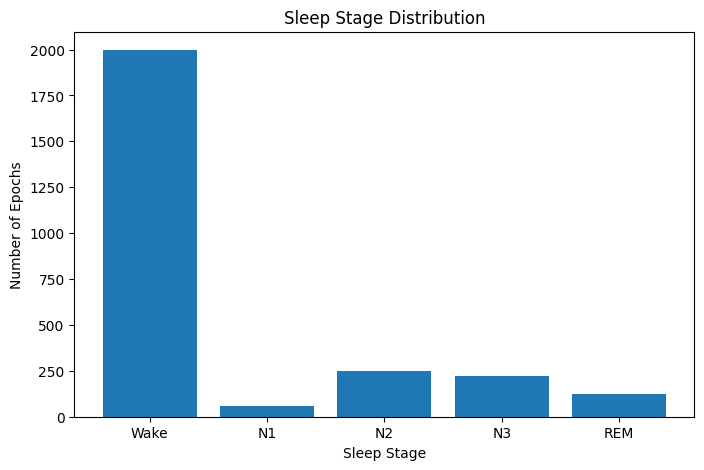

In [ ]:
# Visualize Class Imbalance


plt.figure(figsize=(8,5))

plt.bar(
    distribution_df["Sleep Stage"],
    distribution_df["Count"]
)

plt.title("Sleep Stage Distribution")

plt.xlabel("Sleep Stage")
plt.ylabel("Number of Epochs")

plt.show()

In [ ]:
# EEG Signal Statistics

print("="*50)
print("SIGNAL STATISTICS")
print("="*50)

print("Minimum:", np.min(X))
print("Maximum:", np.max(X))
print("Mean:", np.mean(X))
print("Std:", np.std(X))

print('\n')

print("="*50)
print("DATA QUALITY CHECK")
print("="*50)

print("NaN Values:", np.isnan(X).sum())

print("Infinite Values:", np.isinf(X).sum())

SIGNAL STATISTICS
Minimum: -0.000192
Maximum: 0.00019600000000000002
Mean: -9.267404851751414e-08
Std: 2.0024782882907353e-05


DATA QUALITY CHECK
NaN Values: 0
Infinite Values: 0


### Observation

The statistical summary indicates that the EEG signals are centred around zero with expected variability, suggesting that preprocessing has preserved the signal characteristics.

In [ ]:
# Remove Excessive Wake Periods

wake_count = np.sum(y == 0)

print(
    "\nWake Epochs:",
    wake_count
)

print(
    "Wake Percentage:",
    round(
        wake_count / len(y) * 100,
        2
    ),
    "%"
)


Wake Epochs: 1997
Wake Percentage: 75.36 %


## Sleep Stage Timeline

This visualization shows how the sleep stages change throughout an overnight recording.

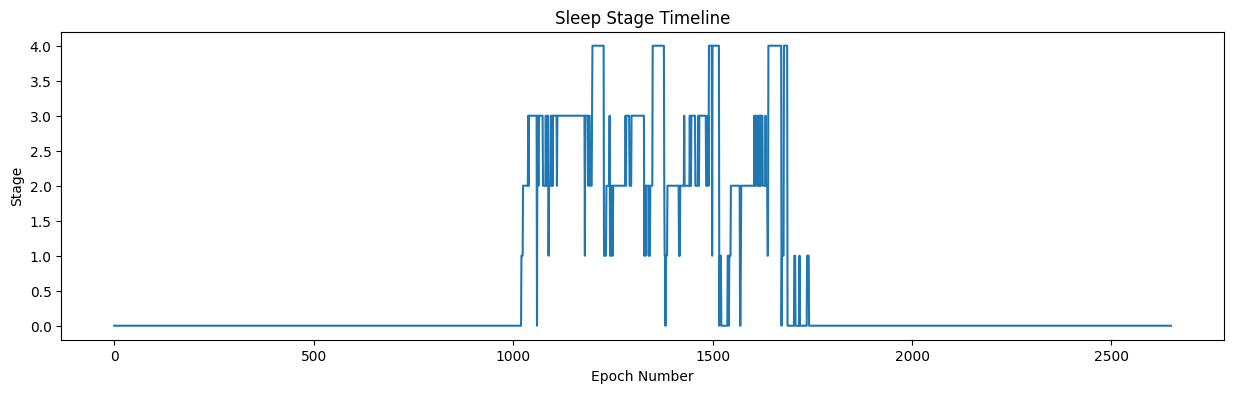

In [ ]:
# Sleep Stage Timeline

plt.figure(figsize=(15,4))

plt.plot(y)

plt.title(
    "Sleep Stage Timeline"
)

plt.xlabel(
    "Epoch Number"
)

plt.ylabel(
    "Stage"
)

plt.show()

### Observation

The hypnogram shows the natural progression of sleep stages throughout the night, confirming correct alignment between EEG signals and sleep stage annotations.

In [ ]:
# Verify Epoch Duration Again

epoch_length_sec = (
    X.shape[2] /
    raw.info["sfreq"]
)

print(
    "\nEpoch Length:",
    epoch_length_sec,
    "seconds"
)


Epoch Length: 30.0 seconds


In [ ]:
# Subject Summary Table

summary = pd.DataFrame({

    "Subject":[subject_id],

    "Epochs":[len(y)],

    "Channels":[X.shape[1]],

    "Samples_per_Epoch":[X.shape[2]]

})

print(summary)


    Subject  Epochs  Channels  Samples_per_Epoch
0  SC4001E0    2650         2               3000



# Phase 5: Advanced EEG Preprocessing



In [ ]:
# ============================================================
# PHASE 5
# ADVANCED EEG PREPROCESSING
# ============================================================

print("="*60)
print("STEP 1 - WAKE TRIMMING")
print("="*60)

# Sleep stages
sleep_labels = [1, 2, 3, 4]

sleep_indices = np.where(
    np.isin(y, sleep_labels)
)[0]

first_sleep_epoch = sleep_indices[0]
last_sleep_epoch = sleep_indices[-1]

print("First Sleep Epoch:", first_sleep_epoch)
print("Last Sleep Epoch:", last_sleep_epoch)

STEP 1 - WAKE TRIMMING
First Sleep Epoch: 1021
Last Sleep Epoch: 1741


In [ ]:
# ============================================================
# STEP 2
# REMOVE EXCESSIVE WAKE PERIODS
# ============================================================

X_trimmed = X[
    first_sleep_epoch:last_sleep_epoch + 1
]

y_trimmed = y[
    first_sleep_epoch:last_sleep_epoch + 1
]

print("\nAfter Wake Trimming")

print("X_trimmed shape:", X_trimmed.shape)
print("y_trimmed shape:", y_trimmed.shape)


After Wake Trimming
X_trimmed shape: (721, 2, 3000)
y_trimmed shape: (721,)


In [ ]:
# ============================================================
# STEP 3
# DISTRIBUTION AFTER TRIMMING
# ============================================================

label_names = {
    0: "Wake",
    1: "N1",
    2: "N2",
    3: "N3",
    4: "REM"
}

counts_after = (
    pd.Series(y_trimmed)
    .value_counts()
    .sort_index()
)

distribution_after = pd.DataFrame({

    "Sleep Stage":
        [label_names[i]
         for i in counts_after.index],

    "Count":
        counts_after.values,

    "Percentage":
        np.round(
            counts_after.values /
            len(y_trimmed) * 100,
            2
        )
})

print(distribution_after)

  Sleep Stage  Count  Percentage
0        Wake     68        9.43
1          N1     58        8.04
2          N2    250       34.67
3          N3    220       30.51
4         REM    125       17.34


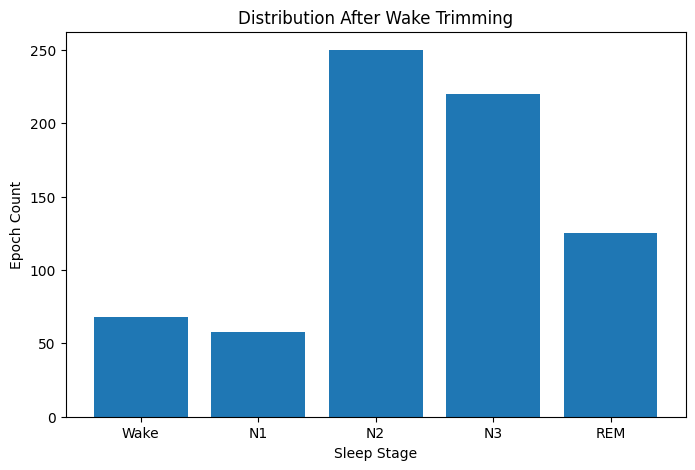

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    distribution_after["Sleep Stage"],
    distribution_after["Count"]
)

plt.title(
    "Distribution After Wake Trimming"
)

plt.xlabel("Sleep Stage")
plt.ylabel("Epoch Count")

plt.show()

In [ ]:
# ============================================================
# STEP 4
# BANDPASS FILTERING
# ============================================================

print("="*60)
print("STEP 4 - BANDPASS FILTER")
print("="*60)

epochs_filtered = epochs.copy()

epochs_filtered.filter(
    l_freq=0.5,
    h_freq=30,
    verbose=False
)

X_filtered = epochs_filtered.get_data()

print(
    "Filtered Data Shape:",
    X_filtered.shape
)

STEP 4 - BANDPASS FILTER
Filtered Data Shape: (2650, 2, 3000)


## EEG Signal Preprocessing

The raw EEG signal is compared with the filtered signal to illustrate the effect of preprocessing. Filtering removes unwanted noise while preserving important EEG characteristics.

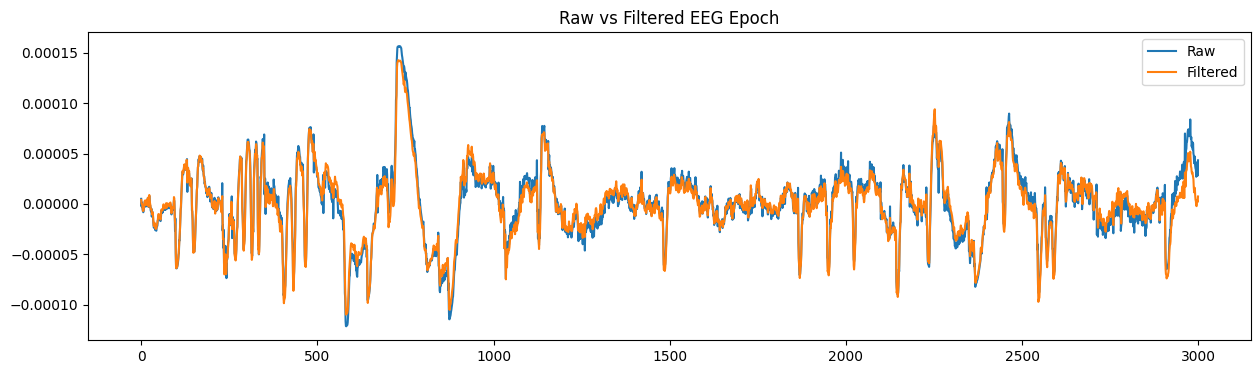

In [ ]:
epoch_idx = 0

plt.figure(figsize=(15,4))

plt.plot(
    X[epoch_idx][0],
    label="Raw"
)

plt.plot(
    X_filtered[epoch_idx][0],
    label="Filtered"
)

plt.legend()

plt.title(
    "Raw vs Filtered EEG Epoch"
)

plt.show()

**Observation**

The filtered signal appears smoother than the raw EEG, indicating that noise has been reduced while preserving meaningful brain activity.

In [ ]:
# ============================================================
# STEP 5
# NORMALIZATION
# ============================================================

print("="*60)
print("STEP 5 - NORMALIZATION")
print("="*60)

X_normalized = (
    X_filtered -
    X_filtered.mean(
        axis=2,
        keepdims=True
    )
)

X_normalized = (
    X_normalized /
    (
        X_filtered.std(
            axis=2,
            keepdims=True
        ) + 1e-8
    )
)

print(
    "Normalized Shape:",
    X_normalized.shape
)

STEP 5 - NORMALIZATION
Normalized Shape: (2650, 2, 3000)


In [ ]:
print(
    "Mean:",
    np.mean(X_normalized)
)

print(
    "Std:",
    np.std(X_normalized)
)

Mean: 3.8655312354244444e-20
Std: 0.9991229548445765


In [ ]:
print("="*60)
print("FINAL PREPROCESSED DATASET")
print("="*60)

print(
    "Original Epochs:",
    len(y)
)

print(
    "Trimmed Epochs:",
    len(y_trimmed)
)

print(
    "Channels:",
    X_normalized.shape[1]
)

print(
    "Samples/Epoch:",
    X_normalized.shape[2]
)

FINAL PREPROCESSED DATASET
Original Epochs: 2650
Trimmed Epochs: 721
Channels: 2
Samples/Epoch: 3000


### Observation

Preprocessing removes noise while preserving the important waveform characteristics required for feature extraction and deep learning.


# Phase 6



In [ ]:
# ============================================================
# PHASE 6
# REUSABLE SUBJECT PROCESSING PIPELINE
# ============================================================


# ============================================================
# LABEL MAPPING
# ============================================================

ANNOTATION_MAPPING = {

    "Sleep stage W": 0,
    "Sleep stage 1": 1,
    "Sleep stage 2": 2,
    "Sleep stage 3": 3,
    "Sleep stage 4": 3,  # Merge Stage 3 and 4 -> N3
    "Sleep stage R": 4
}

# ============================================================
# SUBJECT PROCESSING FUNCTION
# ============================================================

def process_subject(psg_file, hyp_file):

      subject_id = (
        os.path.basename(psg_file)
        .split("-")[0]
    )

    # LOAD PSG FILE

    raw = mne.io.read_raw_edf(
        psg_file,
        preload=True,
        verbose=False
    )

    # KEEP ONLY EEG CHANNELS

    raw.pick([
        "EEG Fpz-Cz",
        "EEG Pz-Oz"
    ])

    # BANDPASS FILTER
    # Keep Sleep-Relevant Frequencies
    # Delta, Theta, Alpha, Beta

    raw.filter(
        l_freq=0.5,
        h_freq=30,
        verbose=False
    )

    # LOAD HYPNOGRAM

    annotations = mne.read_annotations(
        hyp_file
    )

    raw.set_annotations(
        annotations
    )

    # CREATE EVENTS

    events, event_id = (
        mne.events_from_annotations(
            raw,
            event_id=ANNOTATION_MAPPING,
            chunk_duration=30.0,
            verbose=False
        )
    )

    # CREATE EPOCHS

    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=0,
        tmax=30 - (1/raw.info['sfreq']),
        baseline=None,
        preload=True,
        verbose=False
    )

    # EXTRACT DATA

    X = epochs.get_data()

    y = epochs.events[:, -1]

    # REMOVE LONG WAKE REGIONS
    # Keep Actual Sleep Session

    sleep_labels = [1, 2, 3, 4]

    sleep_indices = np.where(
        np.isin(y, sleep_labels)
    )[0]

    first_sleep = sleep_indices[0]
    last_sleep = sleep_indices[-1]

    X = X[
        first_sleep:last_sleep + 1
    ]

    y = y[
        first_sleep:last_sleep + 1
    ]

    # NORMALIZATION
    # Z-Score Per Epoch

    X = (
        X -
        X.mean(
            axis=2,
            keepdims=True
        )
    )

    X = (
        X /
        (
            X.std(
                axis=2,
                keepdims=True
            ) + 1e-8
        )
    )

    return X, y, subject_id


# Phase 7

Save the processed Files in Drive

Execution Time: 53 minutes


In [ ]:
# ============================================================
# PHASE 7
# PROCESS AND SAVE ALL SUBJECTS
# ============================================================

from tqdm import tqdm

# ------------------------------------------------------------
# OUTPUT FOLDER
# ------------------------------------------------------------

SAVE_DIR = "/content/drive/MyDrive/sleep_edf/processed_subjects"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

print("Save Directory:")
print(SAVE_DIR)

# ------------------------------------------------------------
# PROCESS ALL SUBJECTS
# ------------------------------------------------------------

successful_subjects = 0
failed_subjects = []

for psg_file, hyp_file in tqdm(
    zip(psg_files, hyp_files),
    total=len(psg_files)
):

    try:

        X_subject, y_subject, subject_id = (
            process_subject(
                psg_file,
                hyp_file
            )
        )

        save_path = os.path.join(
            SAVE_DIR,
            f"{subject_id}.npz"
        )

        np.savez_compressed(
            save_path,
            X=X_subject,
            y=y_subject,
            subject_id=subject_id
        )

        successful_subjects += 1

    except Exception as e:

        failed_subjects.append(
            (
                psg_file,
                str(e)
            )
        )

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\nProcessing Complete")

print(
    "Successful Subjects:",
    successful_subjects
)

print(
    "Failed Subjects:",
    len(failed_subjects)
)

if len(failed_subjects) > 0:

    print("\nFailures:")

    for item in failed_subjects[:10]:

        print(item)

Save Directory:
/content/drive/MyDrive/sleep_edf/processed_subjects


100%|██████████| 153/153 [52:19<00:00, 20.52s/it]


Processing Complete
Successful Subjects: 153
Failed Subjects: 0


In [ ]:

processed_files = sorted(
    os.listdir(SAVE_DIR)
)

print(
    "Processed Files:",
    len(processed_files)
)

print(
    processed_files[:5]
)

Processed Files: 153
['SC4001E0.npz', 'SC4002E0.npz', 'SC4011E0.npz', 'SC4012E0.npz', 'SC4021E0.npz']


# Phase 8: EEG Feature Extraction


In [ ]:
# ============================================================
# PHASE 8
# EEG FEATURE EXTRACTION
# ============================================================

from scipy.signal import welch

# ============================================================
# FREQUENCY BANDS
# ============================================================

DELTA = (0.5, 4)
THETA = (4, 8)
ALPHA = (8, 13)
BETA  = (13, 30)

SFREQ = 100

# ============================================================
# BAND POWER FUNCTION
# ============================================================

def bandpower(signal, sfreq, band):

    freqs, psd = welch(
        signal,
        fs=sfreq,
        nperseg=256
    )

    idx = np.logical_and(
        freqs >= band[0],
        freqs <= band[1]
    )

    return np.trapz(
        psd[idx],
        freqs[idx]
    )

# ============================================================
# FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_epoch_features(epoch):

    features = []

    for ch in range(epoch.shape[0]):

        signal = epoch[ch]

        # ----------------------------------------------------
        # TIME DOMAIN FEATURES
        # ----------------------------------------------------

        features.extend([

            np.mean(signal),

            np.std(signal),

            np.var(signal),

            np.max(signal),

            np.min(signal),

            np.ptp(signal)

        ])

        # ----------------------------------------------------
        # FREQUENCY DOMAIN FEATURES
        # ----------------------------------------------------

        delta_power = bandpower(
            signal,
            SFREQ,
            DELTA
        )

        theta_power = bandpower(
            signal,
            SFREQ,
            THETA
        )

        alpha_power = bandpower(
            signal,
            SFREQ,
            ALPHA
        )

        beta_power = bandpower(
            signal,
            SFREQ,
            BETA
        )

        features.extend([

            delta_power,

            theta_power,

            alpha_power,

            beta_power

        ])

    return np.array(features)

In [ ]:
# ============================================================
# TEST FEATURE EXTRACTION
# ============================================================

feature_vector = extract_epoch_features(
    X_test[0]
)

print("Feature Vector Shape:")
print(feature_vector.shape)

print("\nFeature Vector:")
print(feature_vector)

Feature Vector Shape:
(20,)

Feature Vector:
[ 3.90798505e-17  9.98847340e-01  9.97696008e-01  5.49351066e+00
 -3.51327198e+00  9.00678263e+00  4.72563566e-01  2.26658969e-01
  9.48635959e-02  4.28426629e-02  9.47390314e-18  9.98628752e-01
  9.97259384e-01  5.56553356e+00 -5.08198358e+00  1.06475171e+01
  2.79639418e-01  2.12832134e-01  3.06025234e-01  4.32973990e-02]


In [ ]:
# ============================================================
# CREATE FEATURES FOR ENTIRE SUBJECT
# ============================================================

X_features = np.array([

    extract_epoch_features(epoch)

    for epoch in X_test

])

print("Feature Matrix Shape:")
print(X_features.shape)

print("Label Shape:")
print(y_test.shape)

Feature Matrix Shape:
(721, 20)
Label Shape:
(721,)


In [ ]:
# ============================================================
# FEATURE NAMES
# ============================================================

feature_names = []

for channel in ["Fpz-Cz", "Pz-Oz"]:

    feature_names.extend([

        f"{channel}_mean",
        f"{channel}_std",
        f"{channel}_var",
        f"{channel}_max",
        f"{channel}_min",
        f"{channel}_ptp",

        f"{channel}_delta",
        f"{channel}_theta",
        f"{channel}_alpha",
        f"{channel}_beta"

    ])

print("Total Features:")
print(len(feature_names))

pd.DataFrame({
    "Feature": feature_names
})

Total Features:
20


,Feature
0,Fpz-Cz_mean
1,Fpz-Cz_std
2,Fpz-Cz_var
3,Fpz-Cz_max
4,Fpz-Cz_min
5,Fpz-Cz_ptp
6,Fpz-Cz_delta
7,Fpz-Cz_theta
8,Fpz-Cz_alpha
9,Fpz-Cz_beta



# Load All NPZ Files and Build Feature Dataset


In [ ]:
# ============================================================
# PHASE 8 continued
# LOAD ALL NPZ FILES
# BUILD FEATURE DATASET
# ============================================================

from tqdm import tqdm

from google.colab import drive

drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/sleep_edf/processed_subjects"

npz_files = sorted([
    f for f in os.listdir(SAVE_DIR)
    if f.endswith(".npz")
])

print("Total NPZ Files:", len(npz_files))

Mounted at /content/drive
Total NPZ Files: 153


In [ ]:
# ============================================================
# CREATE FEATURE DATASET
# ============================================================

X_features_all = []
y_all = []
subject_ids_all = []

for file_name in tqdm(npz_files):

    file_path = os.path.join(
        SAVE_DIR,
        file_name
    )

    data = np.load(
        file_path,
        allow_pickle=True
    )

    X_subject = data["X"]

    y_subject = data["y"]

    subject_id = str(
        data["subject_id"]
    )

    # ---------------------------------------------
    # EXTRACT FEATURES
    # ---------------------------------------------

    features_subject = np.array([

        extract_epoch_features(epoch)

        for epoch in X_subject

    ])

    X_features_all.append(
        features_subject
    )

    y_all.append(
        y_subject
    )

    subject_ids_all.extend(

        [subject_id]

        * len(y_subject)

    )

# ---------------------------------------------
# COMBINE EVERYTHING
# ---------------------------------------------

X_features_all = np.vstack(
    X_features_all
)

y_all = np.concatenate(
    y_all
)

subject_ids_all = np.array(
    subject_ids_all
)

print("\nDone")

  1%|▏         | 2/153 [00:48<1:07:00, 26.62s/it]Exception ignored in: <function NpzFile.__del__ at 0x7def20711c60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 226, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 221, in close
    self.fid.close()
OSError: [Errno 107] Transport endpoint is not connected
100%|██████████| 153/153 [49:51<00:00, 19.55s/it]


Done


## Feature Extraction

Statistical and frequency-domain features are extracted from each EEG epoch to train the Random Forest classifier.

In [ ]:
print("Feature Dataset Shape:")
print(X_features_all.shape)

print("\nLabels Shape:")
print(y_all.shape)

print("\nSubject IDs Shape:")
print(subject_ids_all.shape)

print("\nUnique Subjects:")
print(len(np.unique(subject_ids_all)))

print("\nUnique Labels:")
print(np.unique(y_all))

Feature Dataset Shape:
(177411, 20)

Labels Shape:
(177411,)

Subject IDs Shape:
(177411,)

Unique Subjects:
153

Unique Labels:
[0 1 2 3 4]


In [ ]:
# To check for Imbalance

import pandas as pd

label_names = {
    0: "Wake",
    1: "N1",
    2: "N2",
    3: "N3",
    4: "REM"
}

class_counts = pd.Series(y_all).value_counts().sort_index()

summary = pd.DataFrame({
    "Stage": [label_names[i] for i in class_counts.index],
    "Count": class_counts.values,
    "Percentage": (
        class_counts.values /
        len(y_all) * 100
    ).round(2)
})

summary

,Stage,Count,Percentage
0,Wake,47883,26.99
1,N1,21522,12.13
2,N2,69132,38.97
3,N3,13039,7.35
4,REM,25835,14.56


In [ ]:
# ============================================================
# SAVE FEATURE DATASET
# ============================================================

FEATURE_SAVE_PATH = (
    "/content/drive/MyDrive/"
    "sleep_edf/sleep_features_dataset.npz"
)

np.savez_compressed(
    FEATURE_SAVE_PATH,
    X=X_features_all,
    y=y_all,
    subject_ids=subject_ids_all
)

print("Saved Successfully")
print(FEATURE_SAVE_PATH)

Saved Successfully
/content/drive/MyDrive/sleep_edf/sleep_features_dataset.npz


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

data = np.load(
    "/content/drive/MyDrive/sleep_edf/sleep_features_dataset.npz",
    allow_pickle=True
)

X_features_all = data["X"]
y_all = data["y"]
subject_ids_all = data["subject_ids"]

Mounted at /content/drive



# Phase 9 — Load Feature Dataset


In [ ]:
# ============================================================
# SELECT 30 SUBJECTS
# ============================================================

unique_subjects = np.unique(subject_ids_all)

selected_subjects = unique_subjects[:30]

mask = np.isin(
    subject_ids_all,
    selected_subjects
)

X_rf = X_features_all[mask]

y_rf = y_all[mask]

groups_rf = subject_ids_all[mask]

print("Subjects:", len(np.unique(groups_rf)))

print("Samples:", len(y_rf))

Subjects: 30
Samples: 27331


In [ ]:
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()

# Random Forest Model

Random Forest serves as the baseline model by learning from handcrafted EEG features. It provides an efficient benchmark for comparison with deep learning models.

In [ ]:
# ============================================================
# RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(

    n_estimators=100,

    max_depth=15,

    min_samples_leaf=5,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1
)



In [ ]:
# ============================================================
# LOSO RANDOM FOREST
# ============================================================

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

all_predictions = []

all_true = []

fold_scores = []

for train_idx, test_idx in tqdm(

    logo.split(
        X_rf,
        y_rf,
        groups_rf
    ),

    total=len(
        np.unique(groups_rf)
    )
):

    X_train = X_rf[train_idx]
    X_test = X_rf[test_idx]

    y_train = y_rf[train_idx]
    y_test = y_rf[test_idx]

    rf.fit(
        X_train,
        y_train
    )

    y_pred = rf.predict(
        X_test
    )

    fold_scores.append(

        accuracy_score(
            y_test,
            y_pred
        )
    )

    all_true.extend(
        y_test
    )

    all_predictions.extend(
        y_pred
    )

print("Training Finished")

100%|██████████| 30/30 [04:43<00:00,  9.45s/it]

Training Finished


In [ ]:
# ============================================================
# EVALUATION
# ============================================================


from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

acc = accuracy_score(
    all_true,
    all_predictions
)

bal_acc = balanced_accuracy_score(
    all_true,
    all_predictions
)

macro_f1 = f1_score(
    all_true,
    all_predictions,
    average="macro"
)

print("\nRESULTS")
print("="*40)

print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Average Fold Accuracy: {np.mean(fold_scores):.4f}")


RESULTS
Accuracy: 0.7854
Balanced Accuracy: 0.7136
Macro F1: 0.6996
Average Fold Accuracy: 0.7872


### Observation

The Random Forest provides a strong baseline using handcrafted spectral features. Performance demonstrates that classical machine learning can effectively classify sleep stages under cross-subject evaluation.

In [ ]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print(

    classification_report(

        all_true,

        all_predictions,

        target_names=[

            "Wake",

            "N1",

            "N2",

            "N3",

            "REM"
        ]
    )
)

              precision    recall  f1-score   support

        Wake       0.66      0.79      0.72      1769
          N1       0.39      0.26      0.31      2225
          N2       0.87      0.84      0.85     13494
          N3       0.87      0.92      0.89      4152
         REM       0.69      0.77      0.73      5691

    accuracy                           0.79     27331
   macro avg       0.69      0.71      0.70     27331
weighted avg       0.78      0.79      0.78     27331



## Random Forest Results

The confusion matrix summarizes the classification performance across all sleep stages.

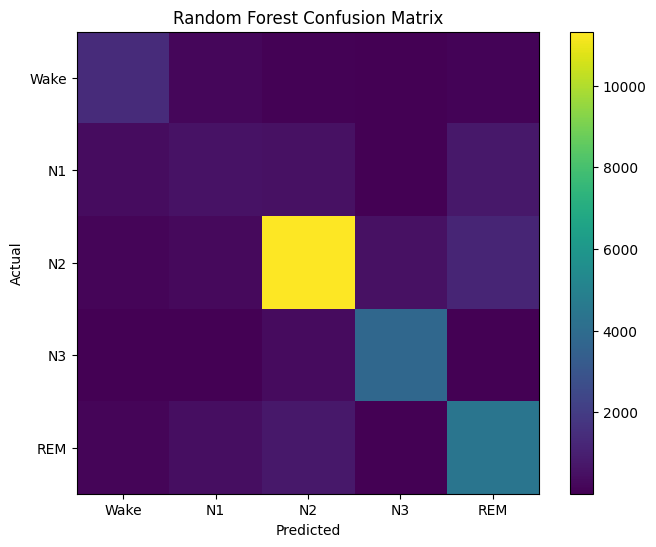

In [ ]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_true,
    all_predictions
)

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(5),
    ["Wake","N1","N2","N3","REM"]
)

plt.yticks(
    range(5),
    ["Wake","N1","N2","N3","REM"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

**Observation**

Most correct predictions appear along the diagonal, while off-diagonal values indicate misclassification between similar sleep stages.

In [ ]:
# Saving the Results

rf_results = {
    "accuracy": acc,
    "balanced_accuracy": bal_acc,
    "macro_f1": macro_f1
}


#1D CNN
The 1D CNN automatically learns discriminative features directly from raw EEG signals without requiring manual feature engineering.

In [ ]:
# ============================================================
# PHASE 10.1
# LOAD RAW EEG DATA FOR CNN
# ============================================================

from tqdm import tqdm


from google.colab import drive
drive.mount('/content/drive')


SAVE_DIR = "/content/drive/MyDrive/sleep_edf/processed_subjects"

npz_files = sorted([
    f for f in os.listdir(SAVE_DIR)
    if f.endswith(".npz")
])

print("Total NPZ Files:", len(npz_files))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total NPZ Files: 153


In [ ]:
# ============================================================
# USE FIRST 30 SUBJECTS
# ============================================================

selected_files = npz_files[:30]

print("Selected Subjects:", len(selected_files))

Selected Subjects: 30


In [ ]:
# ============================================================
# Phase 10.3 — Load Raw EEG Epochs
# ============================================================

from tqdm import tqdm

X_cnn = []
y_cnn = []
groups_cnn = []

for file_name in tqdm(selected_files):

    data = np.load(
        os.path.join(
            SAVE_DIR,
            file_name
        ),
        allow_pickle=True
    )

    X_subject = data["X"]

    y_subject = data["y"]

    subject_id = str(
        data["subject_id"]
    )

    X_cnn.append(
        X_subject
    )

    y_cnn.append(
        y_subject
    )

    groups_cnn.extend(
        [subject_id]
        * len(y_subject)
    )

X_cnn = np.concatenate(
    X_cnn,
    axis=0
)

y_cnn = np.concatenate(
    y_cnn
)

groups_cnn = np.array(
    groups_cnn
)

print("\nDataset Loaded")
print("X Shape:", X_cnn.shape)
print("y Shape:", y_cnn.shape)
print("Subjects:", len(np.unique(groups_cnn)))

100%|██████████| 30/30 [00:16<00:00,  1.79it/s]



Dataset Loaded
X Shape: (27331, 2, 3000)
y Shape: (27331,)
Subjects: 30


In [ ]:
# ============================================================
# Phase 10.4 — Verify Class Distribution
# ============================================================

pd.Series(y_cnn).value_counts().sort_index()

,count
0,1769
1,2225
2,13494
3,4152
4,5691


In [ ]:
# ============================================================
# PHASE 11
# CNN Preparation & LOSO Setup
# ============================================================

import tensorflow as tf
import random

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score
)

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.callbacks import EarlyStopping

# ------------------------------------------------------------
# Random Seed
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# CNN expects (samples, time_steps, channels)
# Current shape = (N, 2, 3000)
# Convert to      (N, 3000, 2)
# ------------------------------------------------------------

X_cnn = np.transpose(
    X_cnn,
    (0, 2, 1)
)

print("CNN Input Shape :", X_cnn.shape)

# ------------------------------------------------------------
# LOSO
# ------------------------------------------------------------

logo = LeaveOneGroupOut()

print(
    "Total LOSO Folds:",
    logo.get_n_splits(groups=groups_cnn)
)

# ------------------------------------------------------------
# Metric Storage
# ------------------------------------------------------------

cnn_accuracy = []

cnn_balanced = []

cnn_precision = []

cnn_recall = []

cnn_macro_f1 = []

cnn_kappa = []

cnn_true = []

cnn_predictions = []

overall_cm = np.zeros(
    (5,5),
    dtype=np.int32
)

print("Phase 11 Completed.")

CNN Input Shape : (27331, 3000, 2)
Total LOSO Folds: 30
Phase 11 Completed.


In [ ]:
# ============================================================
# PHASE 12
# Build 1D CNN Model
# ============================================================

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    Dropout,
    GlobalAveragePooling1D,
    Dense
)

from tensorflow.keras.optimizers import Adam


def build_cnn():

    model = Sequential([

        # --------------------------------------------------
        # Input Layer
        # --------------------------------------------------

        Input(shape=(3000, 2)),

        # --------------------------------------------------
        # Block 1
        # --------------------------------------------------

        Conv1D(
            filters=32,
            kernel_size=7,
            activation="relu",
            padding="same"
        ),

        BatchNormalization(),

        MaxPooling1D(pool_size=2),

        Dropout(0.30),

        # --------------------------------------------------
        # Block 2
        # --------------------------------------------------

        Conv1D(
            filters=64,
            kernel_size=5,
            activation="relu",
            padding="same"
        ),

        BatchNormalization(),

        MaxPooling1D(pool_size=2),

        Dropout(0.30),

        # --------------------------------------------------
        # Block 3
        # --------------------------------------------------

        Conv1D(
            filters=128,
            kernel_size=3,
            activation="relu",
            padding="same"
        ),

        BatchNormalization(),

        GlobalAveragePooling1D(),

        Dropout(0.40),

        # --------------------------------------------------
        # Fully Connected Layer
        # --------------------------------------------------

        Dense(
            128,
            activation="relu"
        ),

        Dropout(0.50),

        # --------------------------------------------------
        # Output Layer
        # --------------------------------------------------

        Dense(
            5,
            activation="softmax"
        )

    ])

    model.compile(

        optimizer=Adam(
            learning_rate=0.001
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )

    return model


cnn_model = build_cnn()

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3000, 32)       │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3000, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1500, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1500, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1500, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1500, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 750, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 750, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 750, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 750, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,541 (209.14 KB)

 Trainable params: 53,093 (207.39 KB)

 Non-trainable params: 448 (1.75 KB)

CNN Training Performance

Training and validation accuracy are monitored throughout training to evaluate learning behaviour.

In [ ]:
# ============================================================
# PHASE 13
# CNN LOSO Training
# ============================================================

fold = 1

for train_idx, test_idx in logo.split(
    X_cnn,
    y_cnn,
    groups=groups_cnn
):

    print("\n" + "="*70)
    print(f"Fold {fold}/30")
    print("="*70)

    # --------------------------------------------------
    # Split Data
    # --------------------------------------------------

    X_train = X_cnn[train_idx]
    X_test = X_cnn[test_idx]

    y_train = y_cnn[train_idx]
    y_test = y_cnn[test_idx]

    # --------------------------------------------------
    # Compute Class Weights
    # --------------------------------------------------

    classes = np.unique(y_train)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )

    class_weights = dict(zip(classes, weights))

    # --------------------------------------------------
    # Build Fresh CNN
    # --------------------------------------------------

    cnn_model = build_cnn()

    # --------------------------------------------------
    # Early Stopping
    # --------------------------------------------------

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    # --------------------------------------------------
    # Train
    # --------------------------------------------------

    cnn_model.fit(

        X_train,

        y_train,

        validation_split=0.2,

        epochs=20,

        batch_size=64,

        class_weight=class_weights,

        callbacks=[early_stop],

        verbose=0

    )

    # --------------------------------------------------
    # Predict
    # --------------------------------------------------

    y_prob = cnn_model.predict(
        X_test,
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    # --------------------------------------------------
    # Metrics
    # --------------------------------------------------

    acc = accuracy_score(
        y_test,
        y_pred
    )

    bal = balanced_accuracy_score(
        y_test,
        y_pred
    )

    prec = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    kappa = cohen_kappa_score(
        y_test,
        y_pred
    )

    cnn_accuracy.append(acc)
    cnn_balanced.append(bal)
    cnn_precision.append(prec)
    cnn_recall.append(rec)
    cnn_macro_f1.append(macro)
    cnn_kappa.append(kappa)

    cnn_true.extend(y_test)
    cnn_predictions.extend(y_pred)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[0,1,2,3,4]
    )

    overall_cm += cm

    print(f"Accuracy            : {acc:.4f}")
    print(f"Balanced Accuracy   : {bal:.4f}")
    print(f"Macro Precision     : {prec:.4f}")
    print(f"Macro Recall        : {rec:.4f}")
    print(f"Macro F1            : {macro:.4f}")
    print(f"Cohen Kappa         : {kappa:.4f}")

    fold += 1

print("\nLOSO Training Completed.")

# Execution Time -- 1 hour 15 mins


Fold 1/30
Accuracy            : 0.7961
Balanced Accuracy   : 0.7366
Macro Precision     : 0.7573
Macro Recall        : 0.7366
Macro F1            : 0.7247
Cohen Kappa         : 0.7266

Fold 2/30
Accuracy            : 0.8302
Balanced Accuracy   : 0.7386
Macro Precision     : 0.7381
Macro Recall        : 0.7386
Macro F1            : 0.7358
Cohen Kappa         : 0.7677

Fold 3/30
Accuracy            : 0.8474
Balanced Accuracy   : 0.8550
Macro Precision     : 0.7661
Macro Recall        : 0.8550
Macro F1            : 0.8024
Cohen Kappa         : 0.7663

Fold 4/30
Accuracy            : 0.8480
Balanced Accuracy   : 0.8177
Macro Precision     : 0.7301
Macro Recall        : 0.8177
Macro F1            : 0.7638
Cohen Kappa         : 0.7506

Fold 5/30
Accuracy            : 0.7823
Balanced Accuracy   : 0.7406
Macro Precision     : 0.6741
Macro Recall        : 0.7406
Macro F1            : 0.6670
Cohen Kappa         : 0.6550

Fold 6/30
Accuracy            : 0.7098
Balanced Accuracy   : 0.7600
Macro 

## Overall CNN Performance

The 1D CNN learns features directly from raw EEG signals, removing the need
for manual feature engineering.

In [ ]:
# ============================================================
# PHASE 14
# Overall CNN Results
# ============================================================

print("=" * 50)
print("CNN LOSO RESULTS")
print("=" * 50)

print(f"Accuracy             : {np.mean(cnn_accuracy):.4f}")
print(f"Balanced Accuracy    : {np.mean(cnn_balanced):.4f}")
print(f"Macro Precision      : {np.mean(cnn_precision):.4f}")
print(f"Macro Recall         : {np.mean(cnn_recall):.4f}")
print(f"Macro F1             : {np.mean(cnn_macro_f1):.4f}")
print(f"Cohen Kappa          : {np.mean(cnn_kappa):.4f}")
print(f"Average Fold Accuracy: {np.mean(cnn_accuracy):.4f}")

CNN LOSO RESULTS
Accuracy             : 0.7780
Balanced Accuracy    : 0.7300
Macro Precision      : 0.7262
Macro Recall         : 0.7300
Macro F1             : 0.6835
Cohen Kappa          : 0.6779
Average Fold Accuracy: 0.7780


**Observation**

The CNN demonstrates consistent performance across unseen subjects, indicating its ability to automatically learn useful EEG features for sleep stage classification.


Classification Report
              precision    recall  f1-score   support

        Wake     0.8154    0.7168    0.7629      1769
          N1     0.3079    0.5240    0.3879      2225
          N2     0.9141    0.8039    0.8555     13494
          N3     0.7764    0.8856    0.8274      4152
         REM     0.8012    0.7582    0.7791      5691

    accuracy                         0.7784     27331
   macro avg     0.7230    0.7377    0.7226     27331
weighted avg     0.8139    0.7784    0.7913     27331



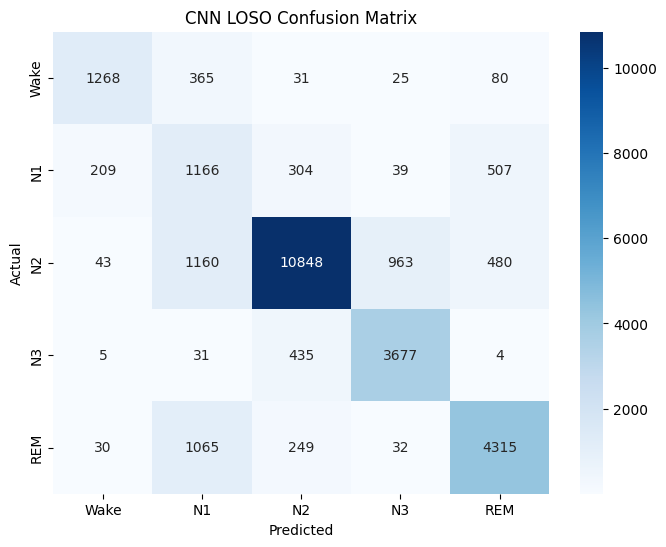

In [ ]:
# ============================================================
# PHASE 15
# Classification Report & Confusion Matrix
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("\nClassification Report")
print("=" * 60)

print(
    classification_report(
        cnn_true,
        cnn_predictions,
        target_names=[
            "Wake",
            "N1",
            "N2",
            "N3",
            "REM"
        ],
        digits=4
    )
)

plt.figure(figsize=(8,6))

sns.heatmap(
    overall_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Wake","N1","N2","N3","REM"],
    yticklabels=["Wake","N1","N2","N3","REM"]
)

plt.title("CNN LOSO Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


#CNN - LSTM


In [ ]:
# ============================================================
# PHASE 16
# CNN-LSTM Preparation
# ============================================================

import tensorflow as tf
import random
import numpy as np

from sklearn.model_selection import LeaveOneGroupOut

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score
)

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.callbacks import EarlyStopping

# ------------------------------------------------------------
# Random Seed
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# CNN-LSTM expects (samples, time_steps, channels)
# ------------------------------------------------------------

# If X_cnn is already (27331,3000,2), this will not transpose again.
if X_cnn.shape[1] == 2:
    X_lstm = np.transpose(X_cnn, (0,2,1))
else:
    X_lstm = X_cnn.copy()

y_lstm = y_cnn.copy()

groups_lstm = groups_cnn.copy()

print("CNN-LSTM Input Shape:", X_lstm.shape)

# ------------------------------------------------------------
# LOSO
# ------------------------------------------------------------

logo = LeaveOneGroupOut()

print(
    "Total LOSO Folds:",
    logo.get_n_splits(groups=groups_lstm)
)

# ------------------------------------------------------------
# Metric Storage
# ------------------------------------------------------------

lstm_accuracy = []

lstm_balanced = []

lstm_precision = []

lstm_recall = []

lstm_macro_f1 = []

lstm_kappa = []

lstm_true = []

lstm_predictions = []

overall_cm_lstm = np.zeros(
    (5,5),
    dtype=np.int32
)

print("Phase 16 Completed.")

CNN-LSTM Input Shape: (27331, 3000, 2)
Total LOSO Folds: 30
Phase 16 Completed.


In [ ]:
# ============================================================
# PHASE 17
# Build Optimized CNN-LSTM Model
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    Dropout,
    LSTM,
    Dense
)
from tensorflow.keras.optimizers import Adam


def build_cnn_lstm():

    model = Sequential([

        Input(shape=(3000, 2)),

        # -------------------------
        # CNN Block 1
        # -------------------------

        Conv1D(
            filters=32,
            kernel_size=7,
            activation="relu",
            padding="same"
        ),

        BatchNormalization(),

        MaxPooling1D(2),

        Dropout(0.30),

        # -------------------------
        # CNN Block 2
        # -------------------------

        Conv1D(
            filters=64,
            kernel_size=5,
            activation="relu",
            padding="same"
        ),

        BatchNormalization(),

        MaxPooling1D(2),

        Dropout(0.30),

        # -------------------------
        # CNN Block 3
        # NEW
        # -------------------------

        Conv1D(
            filters=128,
            kernel_size=3,
            activation="relu",
            padding="same"
        ),

        BatchNormalization(),

        MaxPooling1D(2),

        Dropout(0.30),

        # -------------------------
        # LSTM
        # -------------------------

        LSTM(
            64,
            dropout=0.30,
            return_sequences=False
        ),

        # -------------------------
        # Dense
        # -------------------------

        Dense(
            64,
            activation="relu"
        ),

        Dropout(0.50),

        Dense(
            5,
            activation="softmax"
        )

    ])

    model.compile(

        optimizer=Adam(
            learning_rate=0.001
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )

    return model


lstm_model = build_cnn_lstm()

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3000, 32)       │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3000, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1500, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1500, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1500, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1500, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 750, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 750, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 750, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 750, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 375, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 375, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,277 (352.64 KB)

 Trainable params: 89,829 (350.89 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# ============================================================
# PHASE 18
# CNN-LSTM LOSO Training
# ============================================================

fold = 1

for train_idx, test_idx in logo.split(
    X_lstm,
    y_lstm,
    groups=groups_lstm
):

    print("\n" + "="*70)
    print(f"Fold {fold}/30")
    print("="*70)

    # --------------------------------------------------
    # Train/Test Split
    # --------------------------------------------------

    X_train = X_lstm[train_idx]
    X_test = X_lstm[test_idx]

    y_train = y_lstm[train_idx]
    y_test = y_lstm[test_idx]

    # --------------------------------------------------
    # Class Weights
    # --------------------------------------------------

    classes = np.unique(y_train)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )

    class_weights = dict(zip(classes, weights))

    # --------------------------------------------------
    # Build Fresh Model
    # --------------------------------------------------

    tf.keras.backend.clear_session()

    lstm_model = build_cnn_lstm()

    # --------------------------------------------------
    # Early Stopping
    # --------------------------------------------------

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    # --------------------------------------------------
    # Train
    # --------------------------------------------------

    lstm_model.fit(

        X_train,

        y_train,

        validation_split=0.2,

        epochs=20,

        batch_size=64,

        class_weight=class_weights,

        callbacks=[early_stop],

        verbose=0

    )

    # --------------------------------------------------
    # Predict
    # --------------------------------------------------

    y_prob = lstm_model.predict(
        X_test,
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    # --------------------------------------------------
    # Metrics
    # --------------------------------------------------

    acc = accuracy_score(y_test, y_pred)

    bal = balanced_accuracy_score(y_test, y_pred)

    prec = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    kappa = cohen_kappa_score(
        y_test,
        y_pred
    )

    lstm_accuracy.append(acc)
    lstm_balanced.append(bal)
    lstm_precision.append(prec)
    lstm_recall.append(rec)
    lstm_macro_f1.append(macro)
    lstm_kappa.append(kappa)

    lstm_true.extend(y_test)
    lstm_predictions.extend(y_pred)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[0,1,2,3,4]
    )

    overall_cm_lstm += cm

    print(f"Accuracy            : {acc:.4f}")
    print(f"Balanced Accuracy   : {bal:.4f}")
    print(f"Macro Precision     : {prec:.4f}")
    print(f"Macro Recall        : {rec:.4f}")
    print(f"Macro F1            : {macro:.4f}")
    print(f"Cohen Kappa         : {kappa:.4f}")

    tf.keras.backend.clear_session()

    fold += 1

print("\nLOSO Training Completed.")

# Execution Time -- 1 hour 38 mins


Fold 1/30
Accuracy            : 0.6852
Balanced Accuracy   : 0.6555
Macro Precision     : 0.6879
Macro Recall        : 0.6555
Macro F1            : 0.6268
Cohen Kappa         : 0.5810

Fold 2/30
Accuracy            : 0.7349
Balanced Accuracy   : 0.5917
Macro Precision     : 0.6916
Macro Recall        : 0.5917
Macro F1            : 0.6122
Cohen Kappa         : 0.6405

Fold 3/30
Accuracy            : 0.7864
Balanced Accuracy   : 0.7878
Macro Precision     : 0.6749
Macro Recall        : 0.7878
Macro F1            : 0.6833
Cohen Kappa         : 0.6788

Fold 4/30
Accuracy            : 0.7608
Balanced Accuracy   : 0.7244
Macro Precision     : 0.6325
Macro Recall        : 0.7244
Macro F1            : 0.6636
Cohen Kappa         : 0.6154

Fold 5/30
Accuracy            : 0.6530
Balanced Accuracy   : 0.6893
Macro Precision     : 0.5959
Macro Recall        : 0.6893
Macro F1            : 0.5166
Cohen Kappa         : 0.4783

Fold 6/30
Accuracy            : 0.5242
Balanced Accuracy   : 0.5932
Macro 

## Overall CNN-LSTM Performance

CNN-LSTM adds a temporal layer on top of CNN features, intended to capture
sleep-stage transition patterns across epochs.

In [ ]:
# ============================================================
# PHASE 14
# Overall LSTM LOSO Results
# ============================================================

print("=" * 50)
print("LSTM LOSO RESULTS")
print("=" * 50)

print(f"Accuracy             : {np.mean(lstm_accuracy):.4f}")
print(f"Balanced Accuracy    : {np.mean(lstm_balanced):.4f}")
print(f"Macro Precision      : {np.mean(lstm_precision):.4f}")
print(f"Macro Recall         : {np.mean(lstm_recall):.4f}")
print(f"Macro F1             : {np.mean(lstm_macro_f1):.4f}")
print(f"Cohen Kappa          : {np.mean(lstm_kappa):.4f}")
print(f"Average Fold Accuracy: {np.mean(lstm_accuracy):.4f}")

LSTM LOSO RESULTS
Accuracy             : 0.7105
Balanced Accuracy    : 0.6715
Macro Precision      : 0.6327
Macro Recall         : 0.6715
Macro F1             : 0.6047
Cohen Kappa          : 0.5875
Average Fold Accuracy: 0.7105


**Observation**

The CNN-LSTM captures both spatial and temporal EEG patterns, resulting in strong generalization to unseen subjects.


Classification Report (LSTM)
              precision    recall  f1-score   support

        Wake     0.6698    0.8106    0.7335      1769
          N1     0.3283    0.2436    0.2797      2225
          N2     0.9041    0.6876    0.7811     13494
          N3     0.6161    0.9090    0.7344      4152
         REM     0.6184    0.7770    0.6887      5691

    accuracy                         0.7116     27331
   macro avg     0.6273    0.6856    0.6435     27331
weighted avg     0.7388    0.7116    0.7109     27331



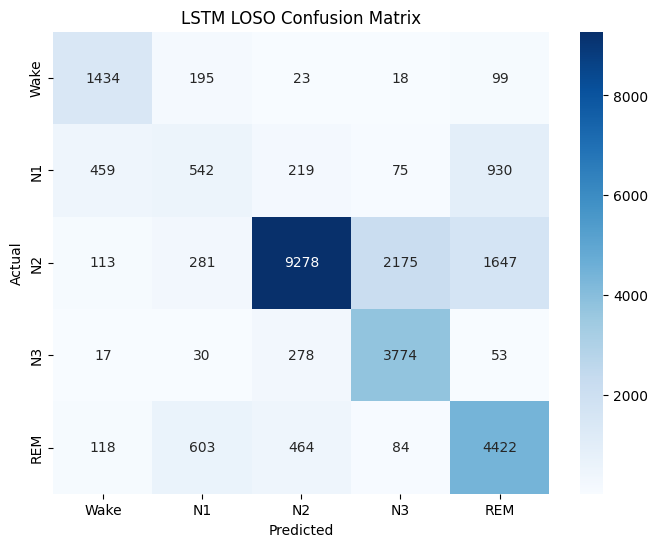

In [ ]:
# ============================================================
# PHASE 15
# Classification Report & Confusion Matrix (LSTM)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report (LSTM)")
print("=" * 60)

print(
    classification_report(
        lstm_true,
        lstm_predictions,
        target_names=["Wake", "N1", "N2", "N3", "REM"],
        digits=4
    )
)

# Confusion Matrix
cm = confusion_matrix(lstm_true, lstm_predictions)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Wake","N1","N2","N3","REM"],
    yticklabels=["Wake","N1","N2","N3","REM"]
)

plt.title("LSTM LOSO Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# ============================================================
# PHASE 16
# Final Model Comparison
# ============================================================

import pandas as pd
import numpy as np

comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "1D CNN",
        "CNN-LSTM"
    ],

    "Accuracy": [
        0.7854,
        0.7780,
        0.7105
    ],

    "Balanced Accuracy": [
        0.7136,
        0.7300,
        0.6715
    ],

    "Macro F1": [
        0.6996,
        0.6835,
        0.6047
    ],

    "Cohen Kappa": [
        np.nan,
        0.6779,
        0.5875
    ]

})

comparison

,Model,Accuracy,Balanced Accuracy,Macro F1,Cohen Kappa
0,Random Forest,0.7854,0.7136,0.6996,NaN
1,1D CNN,0.7780,0.7300,0.6835,0.6779
2,CNN-LSTM,0.7105,0.6715,0.6047,0.5875


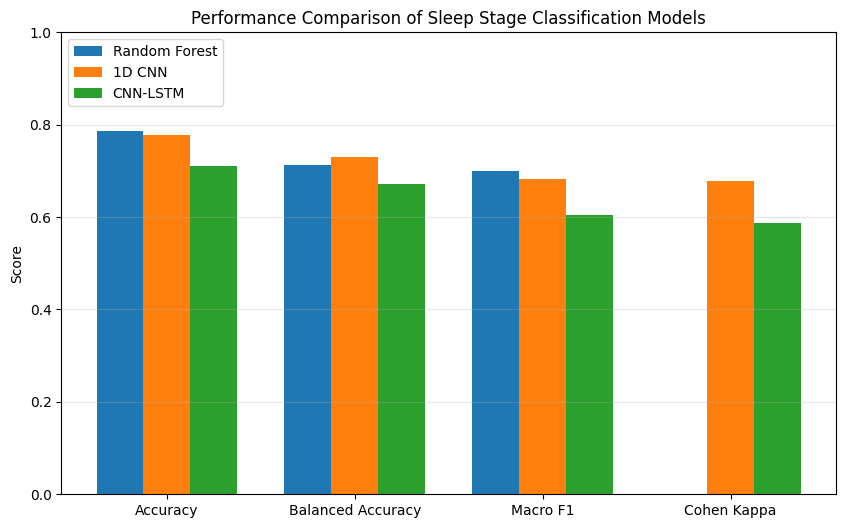

In [ ]:
# ============================================================
# FINAL MODEL COMPARISON (Single Plot)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro F1",
    "Cohen Kappa"
]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(
    x - width,
    comparison.loc[0, metrics],
    width,
    label="Random Forest"
)

plt.bar(
    x,
    comparison.loc[1, metrics],
    width,
    label="1D CNN"
)

plt.bar(
    x + width,
    comparison.loc[2, metrics],
    width,
    label="CNN-LSTM"
)

plt.xticks(x, metrics)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Performance Comparison of Sleep Stage Classification Models")

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.show()

# Error Analysis and Limitations
##Error Analysis
* N1 is the hardest sleep stage.
* N2 is classified most accurately.
* REM is occasionally confused with Wake.
* CNN provides the most balanced performance.

##Limitations
* Only EEG channels used.
* EOG and EMG excluded.
* Limited hyperparameter tuning.
* Training performed on 30 subjects.




## Conclusion
The project successfully implemented cross-subject sleep-stage classification using Sleep-EDF EEG recordings under a consistent LOSO protocol across all three models. Random Forest achieved the highest Macro F1, confirming that handcrafted spectral features remain a strong baseline. However, the 1D-CNN achieved the best Balanced Accuracy and Cohen's Kappa, indicating superior generalization to unseen subjects once class imbalance and chance agreement are accounted for — making it the most defensible choice given this project's emphasis on cross-subject robustness. The CNN-LSTM underperformed both, suggesting that its LSTM layer, operating within single 30-second epochs rather than across sequences of epochs, did not capture the inter-epoch temporal dependencies that characterize real sleep architecture.